In [114]:
# This code is part of QCMet.
# 
# (C) Copyright 2024 National Physical Laboratory and National Quantum Computing Centre 
# 
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
# 
#      http://www.apache.org/licenses/LICENSE-2.0
# 
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License

In [1]:
import qiskit

    
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, minimize

# Relative path to _helpers
import sys
import pathlib
import os
sys.path.insert(0, str(pathlib.Path(os.path.abspath('')).parent.parent.parent.resolve()))
# Disregard any warning on the following imports
from _helpers.circuit_submitter import CircuitSubmitter

#### Ramsey T2* experiment

In [2]:
shots = 1024
max_num_identities = 1000
num_identities = np.arange(1,max_num_identities, 50)
results = {}
circuits = []
for i in num_identities:
    qc = qiskit.QuantumCircuit(1)
    qc.sx(0)
    for _ in range(int(i)):
        qc.id(0)
        qc.barrier()
        qc.rz(np.pi/100,0) # simulating detuned qubit pulse
    qc.sx(0)
    qc.measure_all()
    circuits.append(qc)


In [3]:
device_name = "noisy_sim"
submitter = CircuitSubmitter(benchmark_name="t2_ramsey", device_name=device_name)
submitter.submit_circuits(shots=shots, qasm_strs=[c.qasm() for c in circuits], skip_asking=True, skip_transpilation=True)
counts_list = submitter.retrieve_counts()
ramsey_probs = [res['1']/shots for res in counts_list]

NoiseModel:
  Basis gates: ['cx', 'id', 'rz', 'sx']
  Instructions with noise: ['reset', 'id', 'measure', 'cx', 'sx']
  Qubits with noise: [0, 1, 2, 3]
  Specific qubit errors: [('reset', (0,)), ('reset', (1,)), ('reset', (2,)), ('reset', (3,)), ('measure', (0,)), ('measure', (1,)), ('measure', (2,)), ('measure', (3,)), ('sx', (0,)), ('sx', (1,)), ('sx', (2,)), ('sx', (3,)), ('id', (0,)), ('id', (1,)), ('id', (2,)), ('id', (3,)), ('cx', (0, 0)), ('cx', (0, 1)), ('cx', (0, 2)), ('cx', (0, 3)), ('cx', (1, 0)), ('cx', (1, 1)), ('cx', (1, 2)), ('cx', (1, 3)), ('cx', (2, 0)), ('cx', (2, 1)), ('cx', (2, 2)), ('cx', (2, 3)), ('cx', (3, 0)), ('cx', (3, 1)), ('cx', (3, 2)), ('cx', (3, 3))]
Ready to run 20 circuits on noisy_sim with 1024 shots.
Cost: 20 * ($0 + 1024 * $0) = $0.00.
Circuits have been submitted
2024-07-02 12:53:37 All circuits are finished


In [27]:
def ramsey_fit_func(x, amp, dr, f, phi, b):
    return amp * np.exp(x * -1 / dr)*np.cos(2*np.pi*f*x + phi) + b


In [28]:
# This fit is very sensitive to initial parameters. p0 must be chosen carefully
popt_ramsey, pcov_ramsey = curve_fit(ramsey_fit_func, num_identities, ramsey_probs, p0=[0.5, 1400, np.pi/630, 0, 0.5],  method='trf', maxfev= 50000)
std = np.sqrt(np.diag(pcov_ramsey))
x_to_fit = np.linspace(0,1000,5000)
fitted_probs = ramsey_fit_func(x_to_fit, *popt_ramsey)
fitted_probs = np.around(fitted_probs, decimals=4)

[4.97077980e-01 1.44430041e+03 4.99950007e-03 2.93682056e-02
 5.04732297e-01]


The T2* Ramsey time is : 1444.3004118958115 in units of the number of 1 qubit gates


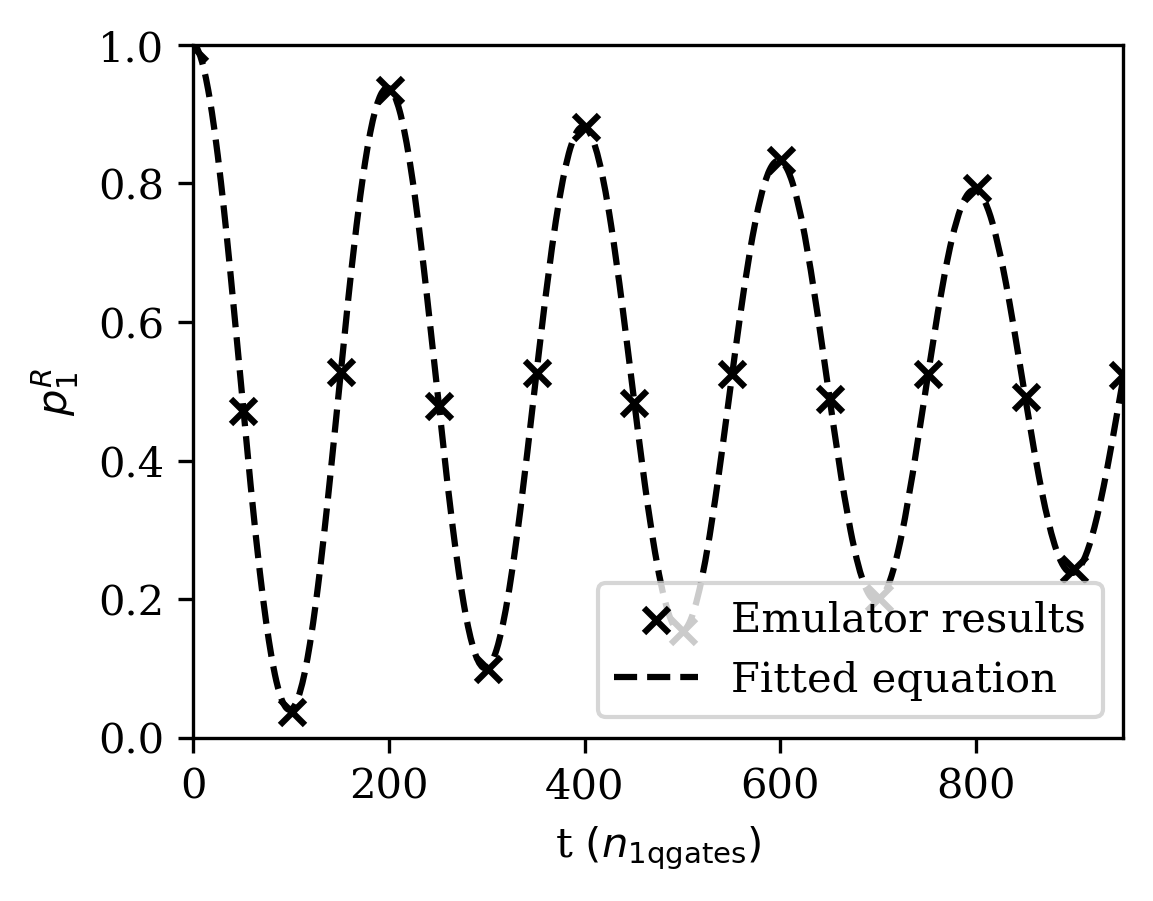

In [29]:
print(f'The T2* Ramsey time is : {popt_ramsey[1]} in units of the number of 1 qubit gates')

fig = plt.figure(figsize=(4,3), dpi=300)
plt.rc('font', family='serif')
plt.xlim((0,num_identities[-1])) 
plt.ylim((0,1))
plt.xlabel(r't $(n_{\mathrm{1q gates}})$')
plt.ylabel(r'$p_1^{R}$')
plt.scatter(num_identities, ramsey_probs, color='black', marker='x', label = 'Emulator results')
plt.plot(x_to_fit, fitted_probs, color='black', ls='--', label='Fitted equation')
plt.gca().tick_params(axis='both', which='both', direction='out')
plt.legend()
plt.show()


### Hahn echo experiment

In [5]:
max_num_identities = 2000
num_identities = np.arange(1,max_num_identities, 100)
results = {}
hahn_circuits = []
for i in num_identities:
    qc = qiskit.QuantumCircuit(1)
    qc.sx(0)
    # circ_tnoise = qiskit.transpile(qc, backend)
    for _ in range(int(i/2)):
        qc.id(0)
        qc.rz(np.pi/100,0) # simulating detuned qubit pulse
    qc.sx(0)
    qc.sx(0)
    for _ in range(int(i/2)):
        qc.id(0)
        qc.rz(np.pi/100,0) # simulating detuned qubit pulse
    qc.sx(0)
    qc.measure_all()
    hahn_circuits.append(qc)

In [6]:
device_name = "noisy_sim"
submitter = CircuitSubmitter(benchmark_name="t2_hahn", device_name=device_name)
submitter.submit_circuits(shots=shots, qasm_strs=[c.qasm() for c in hahn_circuits], skip_asking=True, skip_transpilation=True)
counts_list = submitter.retrieve_counts()
hahn_probs = [res['0']/shots for res in counts_list]

Ready to run 20 circuits on noisy_sim with 1024 shots.
Cost: 20 * ($0 + 1024 * $0) = $0.00.
Circuits have been submitted
2024-07-02 12:54:58 All circuits are finished


In [19]:
def hahn_fit_func(x, amp, dr, b):
    return amp * np.exp(x * -1 / dr) + b

popt_hahn, pcov_hahn = curve_fit(hahn_fit_func, num_identities, hahn_probs, p0=[0.5, 1400, 0.5],  method='trf', maxfev= 5000)
std = np.sqrt(np.diag(pcov_hahn))
x_to_fit = np.linspace(0,2000,5000)
fitted_probs = hahn_fit_func(x_to_fit, *popt_hahn)


The T2 Hahn time is : 1554.5560500037525 in units of the number of 1 qubit gates


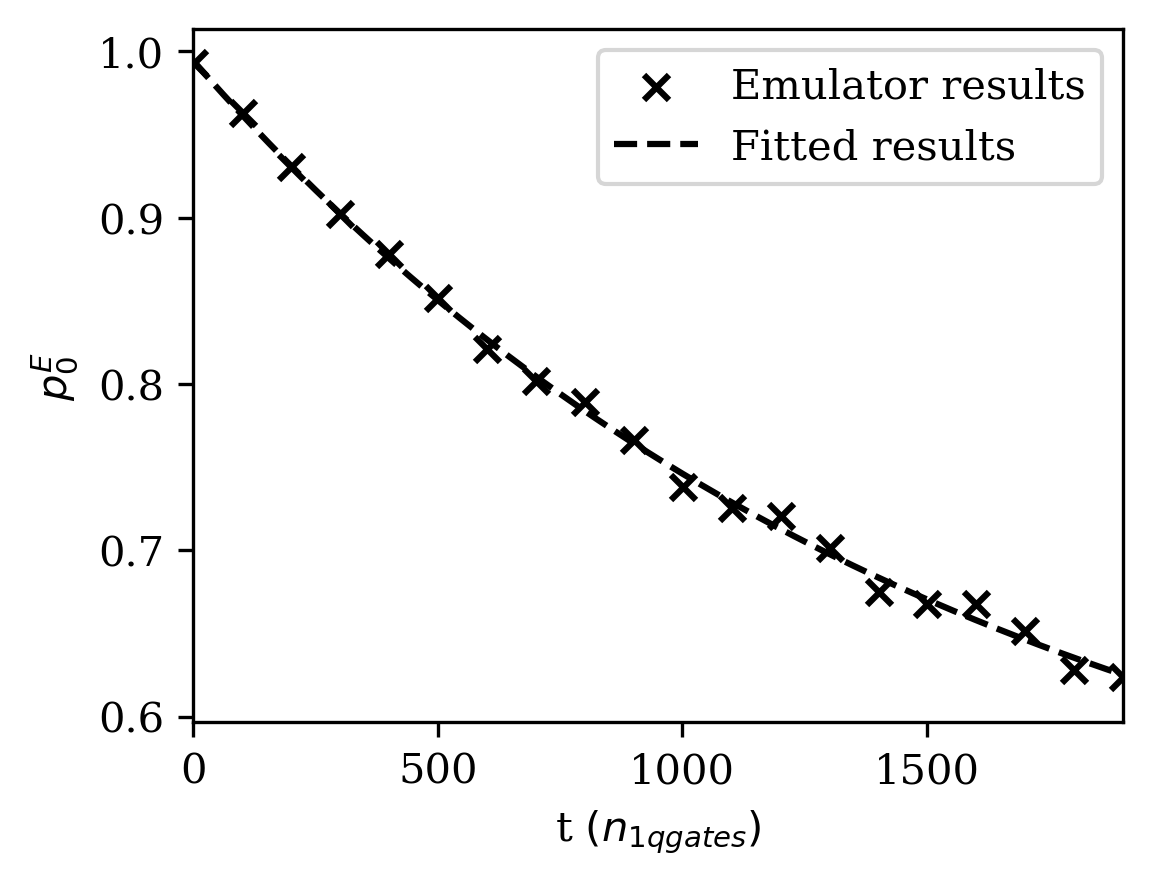

In [21]:
print(f'The T2 Hahn time is : {popt_hahn[1]} in units of the number of 1 qubit gates')

fig = plt.figure(figsize=(4,3), dpi=300)
plt.rc('font', family='serif')
plt.xlim((0,max_num_identities)) 
# plt.ylim((0.7,1))
plt.xlabel(r't $(n_{1q gates})$')
plt.ylabel(r'$p_0^{E}$')
plt.scatter(num_identities, hahn_probs, marker = 'x', color = 'black',label = 'Emulator results')
plt.plot(x_to_fit, fitted_probs, ls = '--', color = 'black', label='Fitted results')
plt.gca().tick_params(axis='both', which='both', direction='out')
plt.legend()
plt.show()
